<a href="https://colab.research.google.com/github/shruti956/A-Version-Control-System-/blob/main/california_housing_value_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# California Housing Value Prediction Using Linear Regression

This project implements multiple linear regression from scratch using NumPy to predict median housing values in California.

The complete machine learning pipeline includes data exploration, train-test splitting, feature normalization, gradient descent, model evaluation, and visualization of predictions.


In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import copy
import math
import matplotlib.pyplot as plt

In [3]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (20640, 9)

Column names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## Preparing Features and Target

The dataset is divided into input features (`X`) and the target variable (`y`). The target, `MedHouseVal`, represents the median house value in units of $100,000.

In [7]:
X = df.drop(columns=["MedHouseVal"]).to_numpy()
y = df["MedHouseVal"].to_numpy()

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (20640, 8)
y shape: (20640,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training examples:", X_train.shape[0])
print("Testing examples:", X_test.shape[0])

Training examples: 16512
Testing examples: 4128


## Feature Scaling

Z-score normalization is applied to the input features so that features with different numerical scales can be handled effectively by gradient descent.

In [9]:
def zscore_normalize_features(X):
    """
    Applies z-score normalization to each feature.
    """
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [10]:
X_train_norm, mu, sigma = zscore_normalize_features(X_train)

X_test_norm = (X_test - mu) / sigma

print("Training data shape:", X_train_norm.shape)
print("Testing data shape:", X_test_norm.shape)

Training data shape: (16512, 8)
Testing data shape: (4128, 8)


## Linear Regression from Scratch

The following functions implement the core components of multiple linear regression: the cost function, gradient computation, and batch gradient descent.

In [11]:
def compute_cost(X, y, w, b):
    """
    Computes the cost for multiple linear regression.
    """
    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        prediction = np.dot(X[i], w) + b
        cost += (prediction - y[i]) ** 2

    cost = cost / (2 * m)

    return cost

In [12]:
def compute_gradient(X, y, w, b):
    """
    Computes the gradients of the cost function
    with respect to w and b.
    """
    m, n = X.shape

    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        error = (np.dot(X[i], w) + b) - y[i]

        for j in range(n):
            dj_dw[j] += error * X[i, j]

        dj_db += error

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_db, dj_dw

In [13]:
def gradient_descent(X, y, w_in, b_in,
                     cost_function, gradient_function,
                     alpha, num_iters):

    J_history = []

    w = copy.deepcopy(w_in)
    b = b_in

    for i in range(num_iters):

        # Calculate gradients
        dj_db, dj_dw = gradient_function(X, y, w, b)

        # Update parameters
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # Record cost
        J_history.append(cost_function(X, y, w, b))

        # Print progress approximately 10 times
        if i % math.ceil(num_iters / 10) == 0:
            print(
                f"Iteration {i:4d}: "
                f"Cost {J_history[-1]:8.4f}"
            )

    return w, b, J_history

In [15]:
# Initialize model parameters
initial_w = np.zeros(X_train_norm.shape[1])
initial_b = 0.0

# Gradient descent settings
alpha = 0.01
num_iters = 1000

# Train the model
w_final, b_final, J_history = gradient_descent(
    X_train_norm,
    y_train,
    initial_w,
    initial_b,
    compute_cost,
    compute_gradient,
    alpha,
    num_iters
)

print("\nFinal weights:", w_final)
print("Final bias:", b_final)

Iteration    0: Cost   2.7650
Iteration  100: Cost   0.6453
Iteration  200: Cost   0.3551
Iteration  300: Cost   0.3094
Iteration  400: Cost   0.2976
Iteration  500: Cost   0.2914
Iteration  600: Cost   0.2866
Iteration  700: Cost   0.2826
Iteration  800: Cost   0.2792
Iteration  900: Cost   0.2763

Final weights: [ 0.82894365  0.17853146 -0.13794939  0.15669182  0.01681517 -0.04522857
 -0.48705563 -0.45147126]
Final bias: 2.071857488844901


## Training Progress

The cost function is plotted against the number of gradient descent iterations to visualize the model's learning progress.

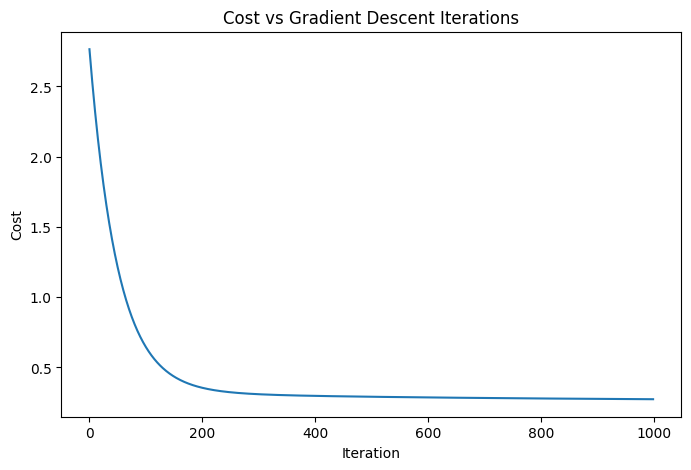

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(J_history)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs Gradient Descent Iterations")

plt.show()

## Model Evaluation

The trained model is evaluated on the unseen test set using MAE, RMSE, and R² score.

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make predictions on the test set
y_pred = np.dot(X_test_norm, w_final) + b_final

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.5476758462432642
Root Mean Squared Error (RMSE): 0.7531170550506763
R² Score: 0.5671692517174325


## Actual vs Predicted Values

The scatter plot compares the model's predicted housing values with the actual values from the test set. Predictions closer to the diagonal reference line indicate more accurate results.

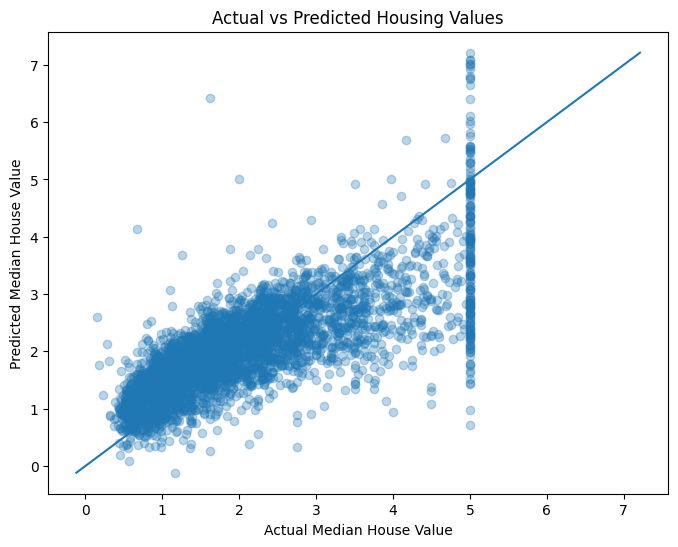

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted Housing Values")

plt.show()

## Sample Predictions

The table below compares actual median housing values with the values predicted by the model for a sample of the test data.

In [19]:
comparison = pd.DataFrame({
    "Actual Value": y_test[:10],
    "Predicted Value": y_pred[:10],
    "Absolute Error": np.abs(y_test[:10] - y_pred[:10])
})

comparison

,Actual Value,Predicted Value,Absolute Error
0,0.47700,0.880748,0.403748
1,0.45800,1.652873,1.194873
2,5.00001,2.502026,2.497984
3,2.18600,2.765361,0.579361
4,2.78000,2.355094,0.424906
5,1.58700,2.093969,0.506969
6,1.98200,2.691306,0.709306
7,1.57500,2.177928,0.602928
8,3.40000,2.353837,1.046163
9,4.46600,4.055600,0.410400


## Example Prediction

The trained model is used to predict the median housing value for one example from the test set. The input features are normalized using the mean and standard deviation calculated from the training data.

In [20]:
example_index = 0

example = X_test[example_index]

# Normalize using training-set statistics
example_norm = (example - mu) / sigma

# Predict
predicted_value = np.dot(example_norm, w_final) + b_final
actual_value = y_test[example_index]

print(f"Predicted median house value: ${predicted_value * 100000:,.2f}")
print(f"Actual median house value:    ${actual_value * 100000:,.2f}")

Predicted median house value: $88,074.77
Actual median house value:    $47,700.00


## Conclusion

This project implemented multiple linear regression from scratch to predict median housing values in California.

The model included:

- Z-score feature normalization
- Cost function computation
- Gradient calculation
- Batch gradient descent
- Evaluation on unseen test data

The model achieved an R² score of approximately **0.57**, explaining about **57% of the variation** in median housing values. The results demonstrate both the usefulness and limitations of a linear model when applied to complex real-world housing data.

Future improvements could include polynomial features, regularization, and nonlinear machine learning models.